



## Import Required Libraries

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Enable cuDNN auto-tuning for faster computation
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.enabled = True
print(f"cuDNN enabled: {torch.backends.cudnn.enabled}, Benchmark: {torch.backends.cudnn.benchmark}")

Using device: cuda
cuDNN enabled: True, Benchmark: True


## Implement the PrunableLinear Layer

The PrunableLinear layer extends nn.Module with learnable gates that multiply each weight. During forward pass:
1. Gate scores are transformed via sigmoid to produce gates ∈ [0, 1]
2. Weights are element-wise multiplied by gates
3. Standard linear operation is performed with pruned weights and bias

In [10]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features, bias=True):
        super(PrunableLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Standard weights and biases for the linear layer
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        if bias:
            self.bias = nn.Parameter(torch.Tensor(out_features))
        else:
            self.register_parameter('bias', None)

        # Learnable gate scores that will be passed through a sigmoid
        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))

        # Initialize weights with Xavier and gates to start ACTIVE (sigmoid(2.0) ≈ 0.88)
        nn.init.xavier_uniform_(self.weight)
        nn.init.constant_(self.gate_scores, 0.0)
        if self.bias is not None:
            nn.init.zeros_(self.bias)

    def forward(self, x):
        # Apply sigmoid to scores to get gates in range [0, 1]
        gates = torch.sigmoid(self.gate_scores)
        # Element-wise multiplication: this is where the 'pruning' happens during training
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores)

    def sparsity_loss(self):
        # We sum the gate values to create a penalty for 'open' gates
        return self.get_gates().sum()

## Build the Prunable Neural Network

Construct a feed-forward network using PrunableLinear layers for CIFAR-10 classification. The network has a convolutional feature extraction stage (not prunable) and a fully connected prunable head.

In [11]:
class PrunableNet(nn.Module):
    def __init__(self):
        super(PrunableNet, self).__init__()
        # Feature extraction layers (standard CNN)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64) # Help with convergence and stability
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)

        # Prunable fully connected head
        self.fc_input_dim = 128 * 8 * 8
        self.fc1 = PrunableLinear(self.fc_input_dim, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 128)
        self.fc4 = PrunableLinear(128, 64)
        self.fc5 = PrunableLinear(64, 10)

    def forward(self, x):
        # Conv blocks
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        # Flatten for the FC layers
        x = x.view(x.size(0), -1)

        # Feed through prunable linear layers with correct output dimensions
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = self.fc5(x)  # Final output: 10 classes for CIFAR-10
        return x

    def get_prunable_layers(self):
        # Helper to easily iterate over layers we want to prune
        return [self.fc1, self.fc2, self.fc3, self.fc4, self.fc5]

    def total_sparsity_loss(self):
        # Aggregate sparsity penalty across the entire network
        return sum(layer.sparsity_loss() for layer in self.get_prunable_layers())

## Define Loss Function with Sparsity Regularization



In [12]:
def compute_loss(model, outputs, targets, lambda_sparsity, layer_lambdas=None):
    """Compute loss with optional layer-specific sparsity regularization.
    
    Args:
        layer_lambdas: List of per-layer lambda multipliers (e.g., [0.1, 0.2, 0.3, 0.6, 1.0])
                      If None, uses uniform lambda across all layers.
    """
    # Standard classification objective
    criterion = nn.CrossEntropyLoss()
    classification_loss = criterion(outputs, targets)

    # Layer-specific sparsity loss (if provided)
    if layer_lambdas is not None:
        sparsity_loss = sum(
            layer_lambda * layer.sparsity_loss() 
            for layer, layer_lambda in zip(model.get_prunable_layers(), layer_lambdas)
        )
    else:
        # Uniform sparsity loss across all layers
        sparsity_loss = model.total_sparsity_loss()

    # Combined objective function
    total_loss = classification_loss + lambda_sparsity * sparsity_loss
    return total_loss, classification_loss, sparsity_loss

## Section 5: Load CIFAR-10 Dataset and Train the Network

Prepare CIFAR-10 data and implement the training loop with Adam optimizer. Train for multiple epochs and track metrics.

In [13]:
class Cutout(object):
    """GPU-optimized cutout that masks out a square patch of the image."""
    def __init__(self, n_holes, length, p=1.0):
        self.n_holes = n_holes
        self.length = length
        self.p = p

    def __call__(self, img):
        if np.random.rand() > self.p:
            return img
        h = img.size(1)
        w = img.size(2)
        mask = torch.ones((h, w), dtype=img.dtype, device=img.device)
        for n in range(self.n_holes):
            y = np.random.randint(h)
            x = np.random.randint(w)
            y1 = max(0, y - self.length // 2)
            y2 = min(h, y + self.length // 2)
            x1 = max(0, x - self.length // 2)
            x2 = min(w, x + self.length // 2)
            mask[y1:y2, x1:x2] = 0.0
        mask = mask.expand_as(img)
        img = img * mask
        return img

# Setup data augmentation and normalization (optimized for GPU)
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Load datasets
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Optimized data loaders: larger batch size, more workers for GPU utilization
num_workers = 4  # Increase for parallel data loading
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=num_workers, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=num_workers, pin_memory=True, persistent_workers=True)

print(f"Data loaders configured: batch_size=256, num_workers={num_workers}, pin_memory=True")

Data loaders configured: batch_size=256, num_workers=4, pin_memory=True


In [14]:
class BestModelCheckpoint:
    """Simple callback to keep track of the best model based on accuracy."""
    def __init__(self):
        self.best_acc = 0.0
        self.best_state = None

    def __call__(self, model, acc):
        if acc > self.best_acc:
            self.best_acc = acc
            # Keep state on GPU for faster restoration
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
            return True
        return False

def train_model(model, train_loader, test_loader, lambda_sparsity, num_epochs=20, warmup_epochs=2, learning_rate=0.001, use_amp=True, gradient_accumulation_steps=1, layer_lambda_factors=None):
    """Train with GPU optimizations: mixed precision, gradient accumulation.
    
    Args:
        layer_lambda_factors: List of per-layer lambda multipliers (default: [0.1, 0.2, 0.3, 0.6, 1.0])
                             Lower values = less pruning for that layer
    """
    # Separate gate parameters from weights
    gate_params = [p for n, p in model.named_parameters() if 'gate_scores' in n]
    other_params = [p for n, p in model.named_parameters() if 'gate_scores' not in n]

    # Optimized optimizer configuration
    optimizer = optim.AdamW([
        {'params': other_params, 'lr': learning_rate},
        {'params': gate_params, 'lr': learning_rate * 2}
    ], eps=1e-8, weight_decay=1e-5)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler = GradScaler(enabled=use_amp)  # Mixed precision gradient scaler
    checkpoint = BestModelCheckpoint()
    history = {'train_loss': [], 'train_acc': [], 'train_sparsity_loss': [], 'test_acc': []}
    model.to(device)
    
    # Layer-specific regularization: lower lambda for early layers (need more capacity)
    if layer_lambda_factors is None:
        layer_lambda_factors = [0.1, 0.2, 0.3, 0.6, 1.0]  # Early layers pruned less
    print(f"Training config: AMP={use_amp}, Gradient Accumulation={gradient_accumulation_steps}, Epochs={num_epochs}")
    print(f"Layer-specific lambda factors: {layer_lambda_factors}")

    for epoch in range(num_epochs):
        model.train()
        current_lambda = 0.0 if epoch < warmup_epochs else lambda_sparsity
        train_loss, correct_train, total_train, total_sparse = 0.0, 0, 0, 0.0
        
        for batch_idx, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            
            # Mixed precision forward pass
            with autocast(enabled=use_amp, dtype=torch.float16):
                outputs = model(inputs)
                # Compute layer-specific lambdas for this epoch
                current_layer_lambdas = [current_lambda * factor for factor in layer_lambda_factors]
                loss, _, sparse_loss = compute_loss(model, outputs, targets, 1.0, layer_lambdas=current_layer_lambdas)
                loss = loss / gradient_accumulation_steps

            # Backward pass with gradient scaling
            scaler.scale(loss).backward()

            # Gradient accumulation step
            if (batch_idx + 1) % gradient_accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            train_loss += loss.item() * gradient_accumulation_steps
            total_sparse += sparse_loss.item()
            _, predicted = outputs.max(1)
            total_train += targets.size(0)
            correct_train += predicted.eq(targets).sum().item()

        scheduler.step()

        # Validation phase (no AMP needed, use eval mode)
        model.eval()
        correct_test, total_test = 0, 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total_test += targets.size(0)
                correct_test += predicted.eq(targets).sum().item()

        test_acc = 100.0 * correct_test / total_test
        checkpoint(model, test_acc)

        # Record metrics
        history['train_acc'].append(100.0 * correct_train / total_train)
        history['test_acc'].append(test_acc)
        history['train_sparsity_loss'].append(total_sparse / len(train_loader))

        if (epoch + 1) % 5 == 0:
            prefix = "[WARMUP] " if epoch < warmup_epochs else ""
            print(f"{prefix}Epoch {epoch+1}: Test Acc={test_acc:.2f}%, Best={checkpoint.best_acc:.2f}%")

    # Load the best weights
    model.load_state_dict(checkpoint.best_state)
    return history

## Section 6: Evaluate Sparsity and Accuracy



In [15]:
def evaluate_sparsity(model, threshold=1e-2):
    """Fast GPU-based sparsity evaluation."""
    model.eval()
    results = {'total_gates': 0, 'pruned_gates': 0, 'sparsity_level': 0.0, 'layer_stats': {}}
    with torch.no_grad():
        for layer_idx, layer in enumerate(model.get_prunable_layers()):
            gates = layer.get_gates()
            # Keep computation on GPU for speed
            pruned = (gates < threshold).sum().item()
            total = gates.numel()

            results['total_gates'] += total
            results['pruned_gates'] += pruned
            results['layer_stats'][f'fc{layer_idx+1}'] = {
                'total': total,
                'pruned': pruned,
                'sparsity': 100.0 * pruned / total,
                'gate_mean': gates.mean().item(),
                'gate_min': gates.min().item(),
                'gate_max': gates.max().item()
            }

    results['sparsity_level'] = 100.0 * results['pruned_gates'] / results['total_gates']
    return results

def evaluate_accuracy(model, test_loader):
    """Fast GPU-based accuracy evaluation with non-blocking transfers."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return 100.0 * correct / total

def print_sparsity_report(sparsity_results, test_accuracy):
    """Prints a clean formatted summary of the model's compression and performance."""
    print("\n" + "="*60)
    print("SPARSITY ANALYSIS REPORT")
    print("="*60)
    print(f"Overall Sparsity Level: {sparsity_results['sparsity_level']:.2f}%")
    print(f"Pruned Gates: {sparsity_results['pruned_gates']}/{sparsity_results['total_gates']}")
    print(f"Test Accuracy: {test_accuracy:.2f}%")

    for layer_name, stats in sparsity_results['layer_stats'].items():
        print(f"\n{layer_name}: Sparsity: {stats['sparsity']:.2f}% | Pruned: {stats['pruned']}/{stats['total']} | Mean: {stats['gate_mean']:.4f}")
    print("="*60)

## Section 7: Compare Results Across Lambda Values

Train and evaluate the network with three different sparsity regularization coefficients (λ values) to demonstrate the sparsity-vs-accuracy trade-off.

In [16]:
lambda_values = [5e-5, 1e-4, 5e-4]  # Much lower values for better balance

results_summary = {}

for lambda_val in lambda_values:
    print(f"\n{'='*70}\nTraining with λ = {lambda_val}\n{'='*70}")
    model = PrunableNet()

    # Train with mixed precision, layer-specific sparsity, and optimized settings for GPU
    # Layer factors: early layers get lower penalties (0.1x, 0.2x), later layers higher (0.7x, 1.0x)
    layer_factors = [0.1, 0.2, 0.3, 0.6, 1.0]  # fc1-fc5: progressively increase pruning pressure
    
    history = train_model(
        model, train_loader, test_loader, 
        lambda_sparsity=lambda_val, 
        num_epochs=40, 
        learning_rate=0.001,
        use_amp=True,  # Mixed precision (FP16)
        gradient_accumulation_steps=1,
        layer_lambda_factors=layer_factors
    )

    sparsity_results = evaluate_sparsity(model, threshold=1e-2)  
    test_accuracy = evaluate_accuracy(model, test_loader)
    print_sparsity_report(sparsity_results, test_accuracy)
    results_summary[lambda_val] = {'history': history, 'sparsity': sparsity_results, 'accuracy': test_accuracy, 'model': model}


Training with λ = 5e-05
Training config: AMP=True, Gradient Accumulation=1, Epochs=40
Layer-specific lambda factors: [0.1, 0.2, 0.3, 0.6, 1.0]


C:\Users\gagan\AppData\Local\Temp\ipykernel_24148\1813932017.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)  # Mixed precision gradient scaler
C:\Users\gagan\AppData\Local\Temp\ipykernel_24148\1813932017.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp, dtype=torch.float16):


Epoch 5: Test Acc=71.16%, Best=71.16%
Epoch 10: Test Acc=73.21%, Best=75.47%
Epoch 15: Test Acc=77.85%, Best=78.52%
Epoch 20: Test Acc=80.54%, Best=80.54%
Epoch 25: Test Acc=81.21%, Best=81.21%
Epoch 30: Test Acc=82.23%, Best=82.61%
Epoch 35: Test Acc=82.76%, Best=82.76%
Epoch 40: Test Acc=82.92%, Best=82.94%

SPARSITY ANALYSIS REPORT
Overall Sparsity Level: 45.26%
Pruned Gates: 1976552/4366976
Test Accuracy: 82.94%

fc1: Sparsity: 45.12% | Pruned: 1892550/4194304 | Mean: 0.0554

fc2: Sparsity: 53.09% | Pruned: 69583/131072 | Mean: 0.1199

fc3: Sparsity: 35.17% | Pruned: 11525/32768 | Mean: 0.1661

fc4: Sparsity: 33.87% | Pruned: 2775/8192 | Mean: 0.2076

fc5: Sparsity: 18.59% | Pruned: 119/640 | Mean: 0.3453

Training with λ = 0.0001
Training config: AMP=True, Gradient Accumulation=1, Epochs=40
Layer-specific lambda factors: [0.1, 0.2, 0.3, 0.6, 1.0]
Epoch 5: Test Acc=69.93%, Best=69.93%
Epoch 10: Test Acc=74.12%, Best=74.46%
Epoch 15: Test Acc=76.77%, Best=76.79%
Epoch 20: Test Acc=7


## Report




### Theoretical Basis: Why Sigmoid + L1 Regularization creates Sparsity

In this implementation, we apply an **L1 penalty** (sum of absolute values) to the output of a **Sigmoid function**. This creates a specific dynamic for the learnable `gate_scores`:

*   **The Gradient Pressure**: The L1 loss is minimized when the gate value is exactly $0$. Since $\text{sigmoid}(x)$ only reaches $0$ as $x \to -\infty$, the optimizer aggressively pushes the `gate_scores` of unimportant weights toward very large negative values.
*   **Effective Pruning**: As the gate output approaches zero, it effectively 'multiplies away' the corresponding weight, meaning that weight no longer contributes to the forward pass or receives meaningful gradients for its value.
*   **Selection**: Only weights that contribute enough to reducing the classification loss to overcome the $\lambda$ penalty will have their gates remain 'open' (closer to 1).

### Results Summary Table
Comparing the regularization strength (λ) against the resulting model size and performance.

In [31]:
# Generate summary table of the experiments
print(f"{'Lambda':<12} | {'Test Accuracy (%)':<20} | {'Sparsity Level (%)':<20}")


for lambda_val in lambda_values:
    res = results_summary[lambda_val]
    acc = res['accuracy']
    sp = res['sparsity']['sparsity_level']
    print(f"{lambda_val:<12.2e} | {acc:<20.2f} | {sp:<20.2f}")


Lambda       | Test Accuracy (%)    | Sparsity Level (%)  
5.00e-05     | 82.94                | 45.26               
1.00e-04     | 82.39                | 49.57               
5.00e-04     | 80.88                | 55.58               


### Visualization of Training History and Trade-offs
We visualize how the model navigated the balance between staying accurate and becoming sparse.

In [32]:
print("Comparison Table: Sparsity vs Accuracy Trade-off")
print(f"{'Lambda':<12} {'Sparsity (%)':<15} {'Test Accuracy (%)':<20}")
for lambda_val in lambda_values:
    results = results_summary[lambda_val]
    sparsity = results['sparsity']['sparsity_level']
    accuracy = results['accuracy']
    print(f"{lambda_val:<12.2e} {sparsity:<15.2f} {accuracy:<20.2f}")


Comparison Table: Sparsity vs Accuracy Trade-off
Lambda       Sparsity (%)    Test Accuracy (%)   
5.00e-05     45.26           82.94               
1.00e-04     49.57           82.39               
5.00e-04     55.58           80.88               


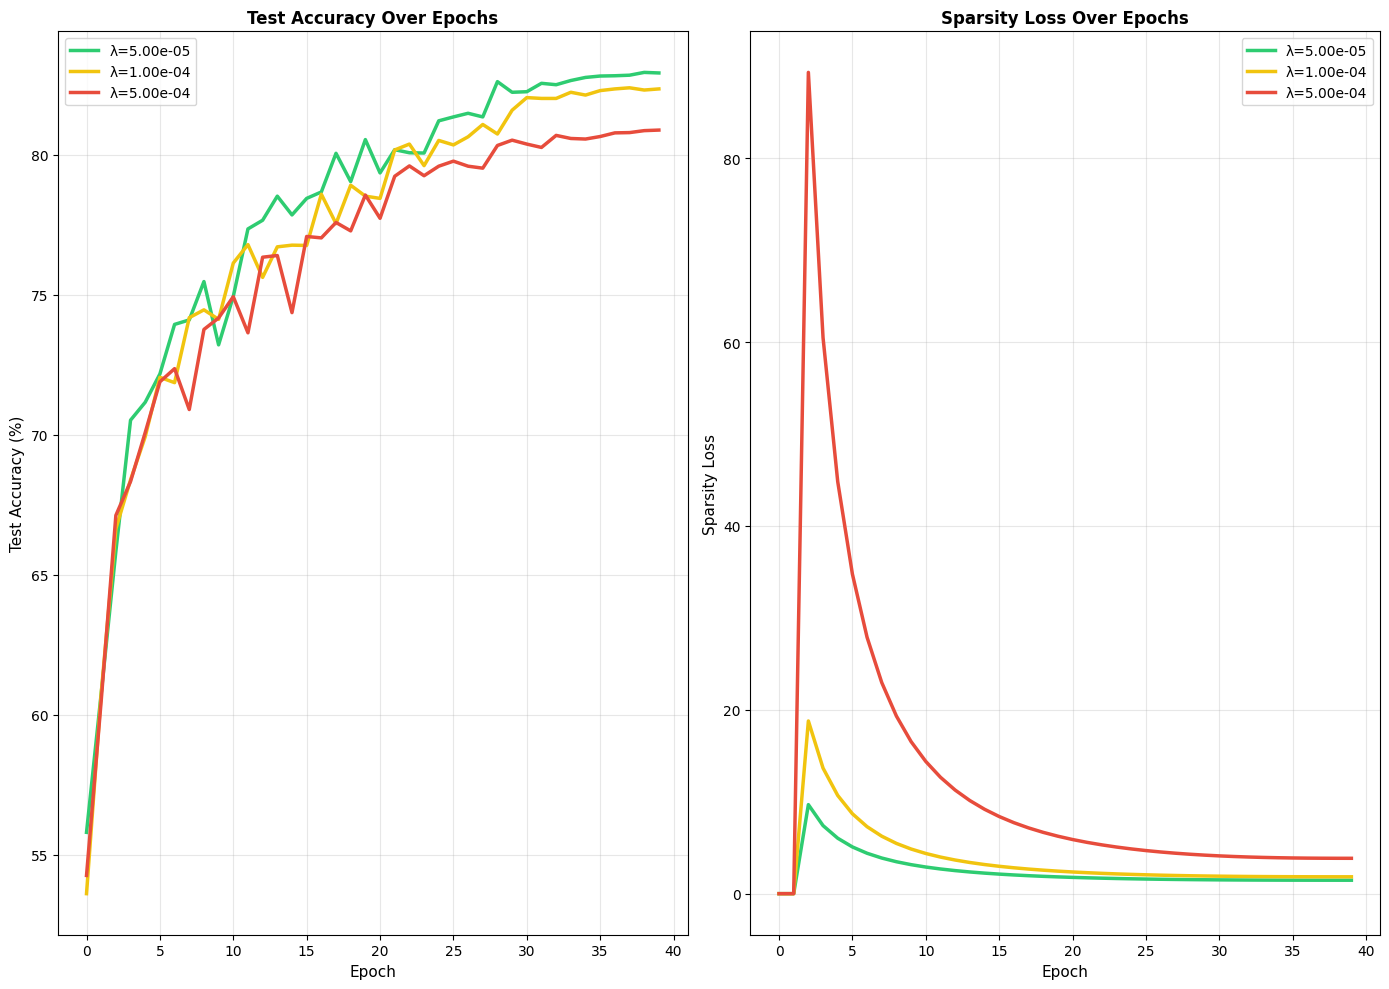

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))


ax = axes[0]
for lam, color in zip(lambda_values, colors):
    history = results_summary[lam]['history']
    ax.plot(history['test_acc'], label=f'λ={lam:.2e}', color=color, linewidth=2.5)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Test Accuracy Over Epochs', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
for lam, color in zip(lambda_values, colors):
    history = results_summary[lam]['history']
    ax.plot(history['train_sparsity_loss'], label=f'λ={lam:.2e}', color=color, linewidth=2.5)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Sparsity Loss', fontsize=11)
ax.set_title('Sparsity Loss Over Epochs', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

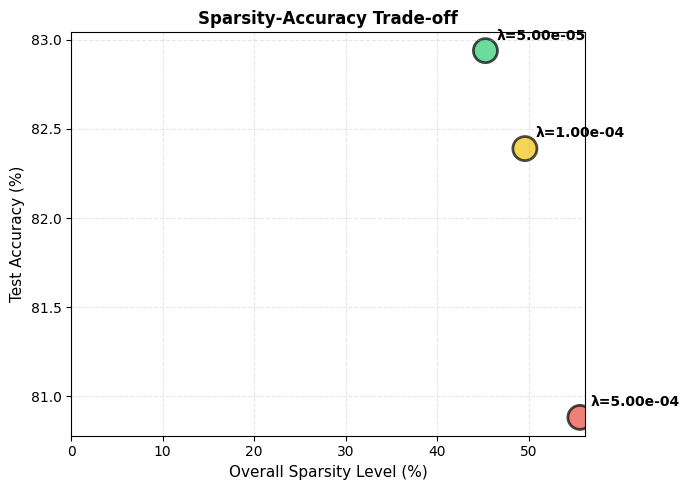

In [ ]:

# Extract values
sparsity_values = [results_summary[lam]['sparsity']['sparsity_level'] for lam in lambda_values]
accuracy_values = [results_summary[lam]['accuracy'] for lam in lambda_values]
labels = [f'λ={lam:.2e}' for lam in lambda_values]

# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 5))

# Scatter plot
scatter = ax.scatter(
    sparsity_values,
    accuracy_values,
    s=300,
    c=colors[:len(lambda_values)],
    alpha=0.7,
    edgecolors='black',
    linewidth=2
)

# Annotate each point
for i, label in enumerate(labels):
    ax.annotate(
        label,
        (sparsity_values[i], accuracy_values[i]),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

# Labels and title
ax.set_xlabel('Overall Sparsity Level (%)', fontsize=11)
ax.set_ylabel('Test Accuracy (%)', fontsize=11)
ax.set_title('Sparsity-Accuracy Trade-off', fontsize=12, fontweight='bold')

# Grid and limits
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(left=0)

# Layout and show
plt.tight_layout()
plt.show()


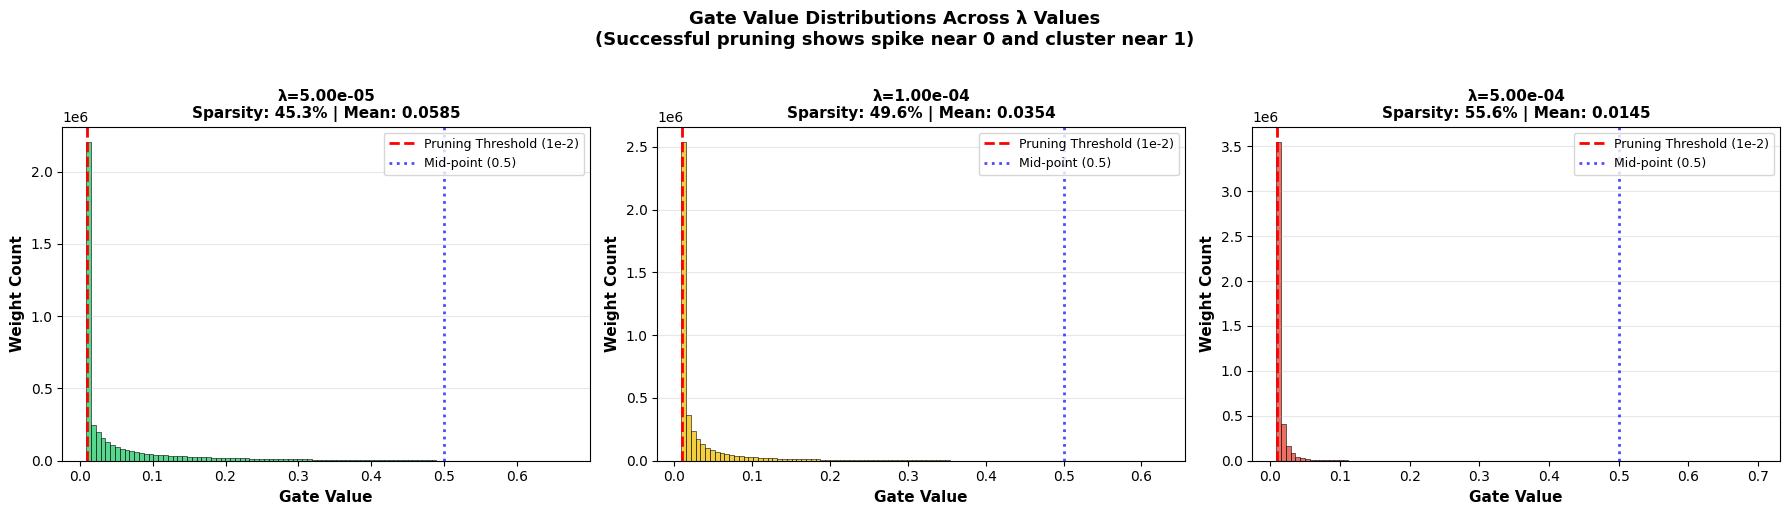

In [25]:
fig, axes = plt.subplots(1, len(lambda_values), figsize=(18, 5))
colors = ['#2ecc71', '#f1c40f', '#e74c3c']  # Green, Yellow, Red

for idx, (lam, ax) in enumerate(zip(lambda_values, axes)):
    model = results_summary[lam]['model']
    all_gates = []
    for layer in model.get_prunable_layers():
        gates_np = layer.get_gates().detach().cpu().numpy().flatten()
        all_gates.extend(gates_np)
    
    all_gates = np.array(all_gates)
    
    # Create histogram with better bins to show spike at 0
    ax.hist(all_gates, bins=100, color=colors[idx], alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.axvline(1e-2, color='red', linestyle='--', linewidth=2, label='Pruning Threshold (1e-2)')
    ax.axvline(0.5, color='blue', linestyle=':', linewidth=2, alpha=0.7, label='Mid-point (0.5)')
    
    # Calculate statistics
    num_pruned = (all_gates < 1e-2).sum()
    num_total = len(all_gates)
    sparsity_pct = 100 * num_pruned / num_total
    mean_gate = all_gates.mean()
    
    ax.set_xlabel('Gate Value', fontsize=11, fontweight='bold')
    ax.set_ylabel('Weight Count', fontsize=11, fontweight='bold')
    ax.set_title(f'λ={lam:.2e}\nSparsity: {sparsity_pct:.1f}% | Mean: {mean_gate:.4f}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=9, loc='upper right')

plt.suptitle('Gate Value Distributions Across λ Values\n(Successful pruning shows spike near 0 and cluster near 1)', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Final Gate Distributions

This histogram shows the 'binary' nature of the learned gates. A successful pruning process shows a large spike at 0.0 (the pruned weights) and a cluster of values near 1.0 (the active weights).

Detailed gate analysis for best Model (λ=5.00e-05)
FC1 (8192→512): 45.1% sparse (1892550/4194304 pruned), Mean gate: 0.0554
FC2 (512→256): 53.1% sparse (69583/131072 pruned), Mean gate: 0.1199
FC3 (256→128): 35.2% sparse (11525/32768 pruned), Mean gate: 0.1661
FC4 (128→64): 33.9% sparse (2775/8192 pruned), Mean gate: 0.2076
FC5 (64→10): 18.6% sparse (119/640 pruned), Mean gate: 0.3453


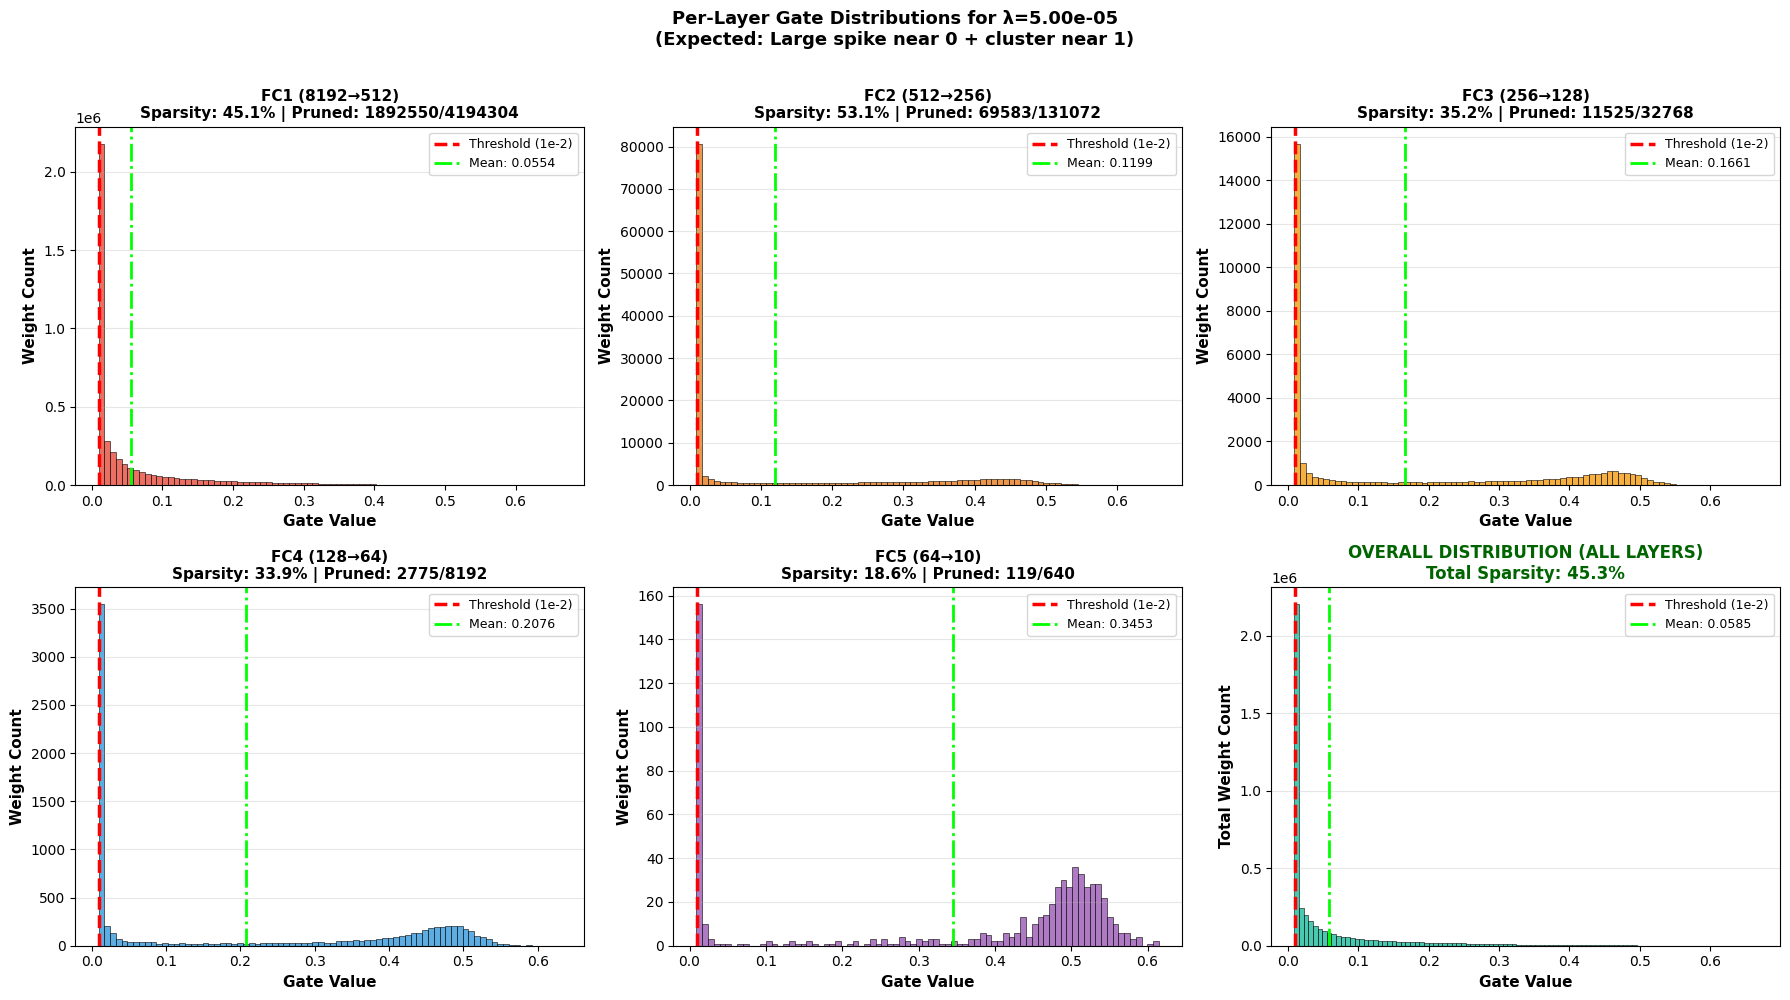

In [43]:
# Detailed analysis: Show per-layer gate distributions for the best model (smallest lambda)
best_lambda = lambda_values[0]  # Most aggressive pruning
best_model = results_summary[best_lambda]['model']


print(f"Detailed gate analysis for best Model (λ={best_lambda:.2e})")


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

layer_names = ['FC1 (8192→512)', 'FC2 (512→256)', 'FC3 (256→128)', 'FC4 (128→64)', 'FC5 (64→10)']
colors_per_layer = ['#e74c3c', '#e67e22', '#f39c12', '#3498db', '#9b59b6']

for layer_idx, (layer, ax, layer_name, color) in enumerate(zip(best_model.get_prunable_layers(), axes[:5], layer_names, colors_per_layer)):
    gates = layer.get_gates().detach().cpu().numpy().flatten()
    
    # Count statistics
    pruned_count = (gates < 1e-2).sum()
    active_count = (gates >= 1e-2).sum()
    total = len(gates)
    sparsity = 100 * pruned_count / total
    
    # Plot histogram
    ax.hist(gates, bins=80, color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.axvline(1e-2, color='red', linestyle='--', linewidth=2.5, label='Threshold (1e-2)')
    ax.axvline(gates.mean(), color='lime', linestyle='-.', linewidth=2, label=f'Mean: {gates.mean():.4f}')
    
    ax.set_xlabel('Gate Value', fontsize=11, fontweight='bold')
    ax.set_ylabel('Weight Count', fontsize=11, fontweight='bold')
    ax.set_title(f'{layer_name}\nSparsity: {sparsity:.1f}% | Pruned: {pruned_count}/{total}', 
                fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=9)
    
    print(f"{layer_name}: {sparsity:.1f}% sparse ({pruned_count}/{total} pruned), Mean gate: {gates.mean():.4f}")

# Summary plot in the 6th subplot
ax = axes[5]
all_gates_summary = []
for layer in best_model.get_prunable_layers():
    all_gates_summary.extend(layer.get_gates().detach().cpu().numpy().flatten())
all_gates_summary = np.array(all_gates_summary)

ax.hist(all_gates_summary, bins=100, color='#1abc9c', alpha=0.8, edgecolor='black', linewidth=0.5)
ax.axvline(1e-2, color='red', linestyle='--', linewidth=2.5, label='Threshold (1e-2)')
ax.axvline(all_gates_summary.mean(), color='lime', linestyle='-.', linewidth=2, label=f'Mean: {all_gates_summary.mean():.4f}')
ax.set_xlabel('Gate Value', fontsize=11, fontweight='bold')
ax.set_ylabel('Total Weight Count', fontsize=11, fontweight='bold')
ax.set_title(f'OVERALL DISTRIBUTION (ALL LAYERS)\nTotal Sparsity: {100*(all_gates_summary < 1e-2).sum()/len(all_gates_summary):.1f}%',
            fontsize=12, fontweight='bold', color='darkgreen')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=9)

plt.suptitle(f'Per-Layer Gate Distributions for λ={best_lambda:.2e}\n(Expected: Large spike near 0 + cluster near 1)', 
             fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

